# Modified Bass Model Homework 2

Ноутбук реализует модифицированную модель Басса для двух компаний, оценивает сходимость,
генерирует датасет для ML и решает обратную задачу.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from modified_bass_model import ModifiedBassModel, generate_dataset

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.float_format', lambda x: f'{x:0.4f}')

def build_features(df, degree):
    pA = df['pA'].to_numpy()
    pB = df['pB'].to_numpy()
    columns = [np.ones(len(df)), pA, pB]
    if degree >= 2:
        columns.extend([pA**2, pA * pB, pB**2])
    if degree >= 3:
        columns.extend([pA**3, (pA**2) * pB, pA * (pB**2), pB**3])
    return np.column_stack(columns)

def fit_polynomial_regression(train_df, target, degree):
    X = build_features(train_df, degree)
    y = target.to_numpy()
    coef, *_ = np.linalg.lstsq(X, y, rcond=None)
    return coef

def predict_polynomial_regression(df, coef, degree):
    X = build_features(df, degree)
    pred = X @ coef
    return np.clip(pred, 0.0, 1.0)

def mae(y_true, y_pred):
    return float(np.mean(np.abs(y_true - y_pred)))

def r2(y_true, y_pred):
    ss_res = float(np.sum((y_true - y_pred) ** 2))
    ss_tot = float(np.sum((y_true - np.mean(y_true)) ** 2))
    return 1.0 - ss_res / ss_tot if ss_tot > 0 else 0.0


## 1. Базовая симуляция

Запускаем модель на 200 шагов и смотрим на динамику рынка.


In [2]:
model = ModifiedBassModel(
    N=10_000,
    pA=0.012,
    qA=0.32,
    pB=0.010,
    qB=0.28,
    disappointment=0.025,
    tolerance=0.08,
    aggression=0.12,
)
history = model.run(steps=200)
history.tail()


,step,potential,A_satisfied,A_neutral,A_dissatisfied,A_total,B_satisfied,B_neutral,B_dissatisfied,B_total,share_A,share_B,cost_A,cost_B
196,196,7.2556,3671.0478,2202.5325,33.2708,5906.8511,2539.7778,1523.9628,22.1527,4085.8934,0.5911,0.4089,24390.8544,16911.4628
197,197,7.1132,3671.5175,2202.8149,32.6239,5906.9562,2540.0721,1524.1388,21.7197,4085.9306,0.5911,0.4089,24390.8976,16911.3778
198,198,6.9737,3671.9780,2203.0917,31.9895,5907.0592,2540.3606,1524.3114,21.2950,4085.9671,0.5911,0.4089,24390.9398,16911.2945
199,199,6.8369,3672.4296,2203.3631,31.3675,5907.1602,2540.6435,1524.4807,20.8787,4086.0029,0.5911,0.4089,24390.9809,16911.2130
200,200,6.7028,3672.8723,2203.6293,30.7575,5907.2592,2540.9208,1524.6466,20.4706,4086.0380,0.5911,0.4089,24391.0210,16911.1331


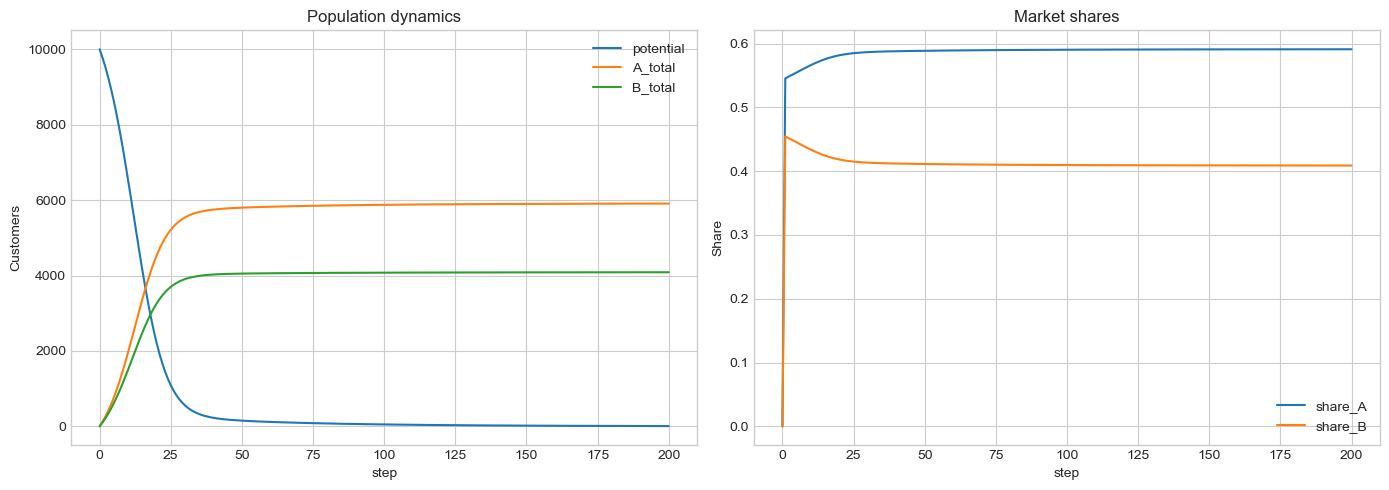

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
history.plot(x='step', y=['potential', 'A_total', 'B_total'], ax=axes[0])
axes[0].set_title('Population dynamics')
axes[0].set_ylabel('Customers')

history.plot(x='step', y=['share_A', 'share_B'], ax=axes[1])
axes[1].set_title('Market shares')
axes[1].set_ylabel('Share')
plt.tight_layout()


## 2. Оценка сходимости

Сходимость считаем достигнутой, если максимальное отклонение `share_A` на последних 20 шагах меньше `1e-3`.


In [4]:
summary = model.convergence_summary(steps=200, window=20, tolerance_value=1e-3)
summary


{'equilibrium_share_A': 0.5911221344481387,
 'equilibrium_share_B': 0.4088778655518613,
 'max_share_deviation': 2.4287137230127875e-05,
 'converged': True}

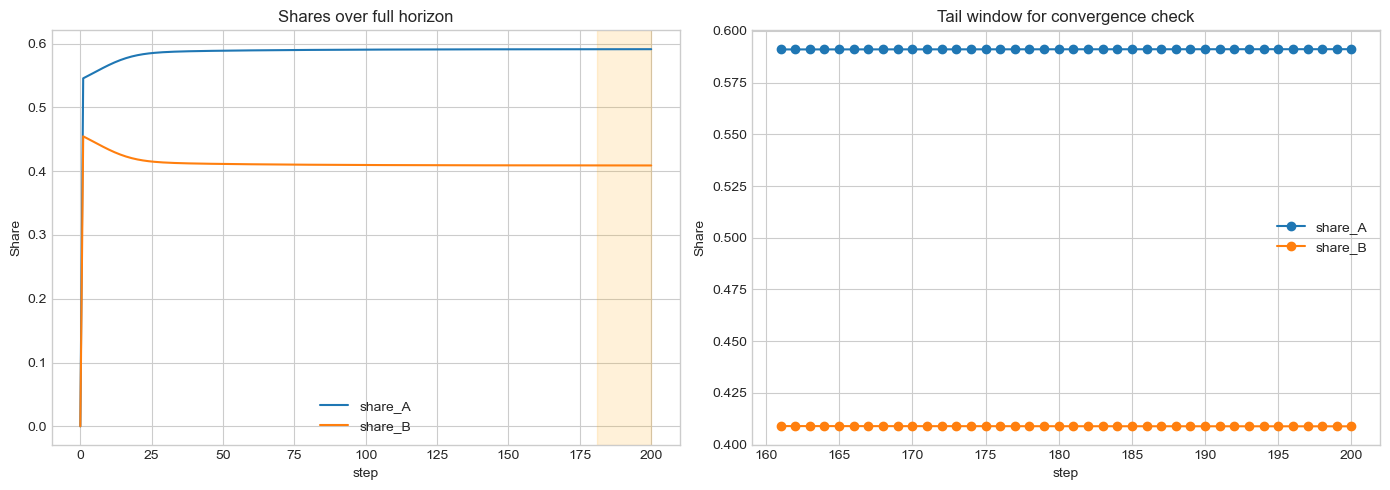

In [5]:
tail_window = history.tail(40).copy()
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

history.plot(x='step', y=['share_A', 'share_B'], ax=axes[0])
axes[0].axvspan(history['step'].iloc[-20], history['step'].iloc[-1], color='orange', alpha=0.15)
axes[0].set_title('Shares over full horizon')
axes[0].set_ylabel('Share')

tail_window.plot(x='step', y=['share_A', 'share_B'], ax=axes[1], marker='o')
axes[1].set_title('Tail window for convergence check')
axes[1].set_ylabel('Share')
plt.tight_layout()


In [6]:
tail_window[['step', 'share_A', 'share_B']].tail(20)


,step,share_A,share_B
181,181,0.5911,0.4089
182,182,0.5911,0.4089
183,183,0.5911,0.4089
184,184,0.5911,0.4089
185,185,0.5911,0.4089
186,186,0.5911,0.4089
187,187,0.5911,0.4089
188,188,0.5911,0.4089
189,189,0.5911,0.4089
190,190,0.5911,0.4089


## 3. Варьирование параметров

Варьируем `pA` и `pB`, остальные параметры фиксируем. Получаем датасет из предельных долей рынка.


In [7]:
pA_values = np.linspace(0.005, 0.050, 16)
pB_values = np.linspace(0.005, 0.050, 16)

dataset = generate_dataset(
    pA_values,
    pB_values,
    qA=0.30,
    qB=0.30,
    disappointment=0.02,
    tolerance=0.05,
    aggression=0.10,
    steps=200,
)
dataset.head()


,pA,pB,share_A,share_B,converged,max_share_deviation
0,0.0050,0.0050,0.5000,0.5000,True,0.0000
1,0.0050,0.0080,0.3846,0.6154,True,0.0000
2,0.0050,0.0110,0.3125,0.6875,True,0.0000
3,0.0050,0.0140,0.2632,0.7368,True,0.0000
4,0.0050,0.0170,0.2273,0.7727,True,0.0000


In [8]:
dataset[['share_A', 'max_share_deviation']].describe()


,share_A,max_share_deviation
count,256.0000,256.0000
mean,0.5000,0.0000
std,0.1963,0.0000
min,0.0909,0.0000
25%,0.3626,0.0000
50%,0.5000,0.0000
75%,0.6374,0.0000
max,0.9091,0.0000


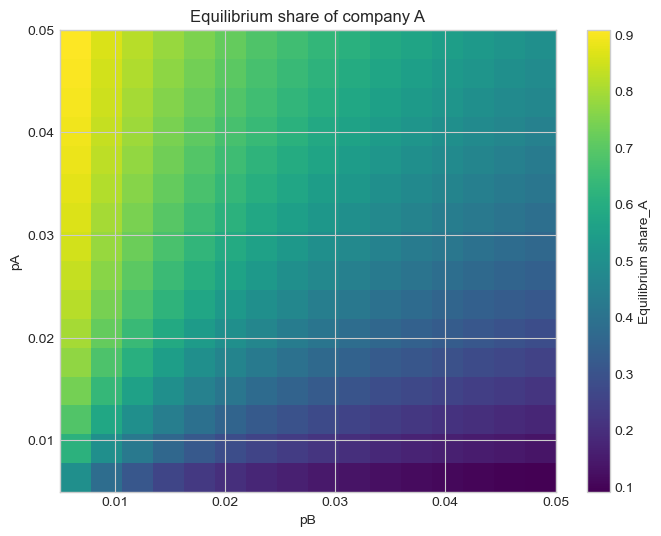

In [9]:
pivot = dataset.pivot(index='pA', columns='pB', values='share_A')

plt.figure(figsize=(8, 6))
plt.imshow(
    pivot.values,
    origin='lower',
    aspect='auto',
    extent=[pivot.columns.min(), pivot.columns.max(), pivot.index.min(), pivot.index.max()],
    cmap='viridis'
)
plt.colorbar(label='Equilibrium share_A')
plt.xlabel('pB')
plt.ylabel('pA')
plt.title('Equilibrium share of company A')
plt.show()


## 4. ML-модель

Сравниваем три регрессионные модели: линейную, квадратичную и кубическую. Все они обучаются через `numpy.linalg.lstsq`.


In [10]:
test_mask = ((dataset.index % 4) == 0)
train_df = dataset.loc[~test_mask, ['pA', 'pB']].reset_index(drop=True)
test_df = dataset.loc[test_mask, ['pA', 'pB']].reset_index(drop=True)
y_train = dataset.loc[~test_mask, 'share_A'].reset_index(drop=True)
y_test = dataset.loc[test_mask, 'share_A'].reset_index(drop=True)

degrees = {
    'linear': 1,
    'quadratic': 2,
    'cubic': 3,
}

results = []
models = {}
for name, degree in degrees.items():
    coef = fit_polynomial_regression(train_df, y_train, degree)
    pred = predict_polynomial_regression(test_df, coef, degree)
    results.append({
        'model': name,
        'degree': degree,
        'mae': mae(y_test.to_numpy(), pred),
        'r2': r2(y_test.to_numpy(), pred),
    })
    models[name] = coef

results_df = pd.DataFrame(results).sort_values('mae').reset_index(drop=True)
results_df


,model,degree,mae,r2
0,cubic,3,0.0090,0.9934
1,quadratic,2,0.0193,0.9756
2,linear,1,0.0491,0.8874


Best model: cubic
MAE: 0.009038711334449147
R2: 0.9933507051874563


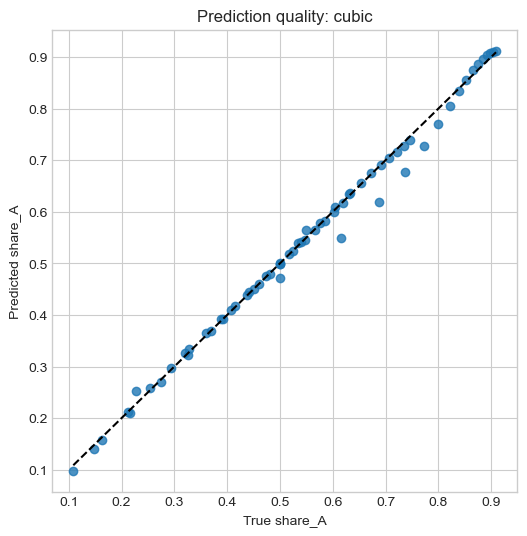

In [11]:
best_model_name = results_df.loc[0, 'model']
best_degree = int(results_df.loc[0, 'degree'])
best_coef = models[best_model_name]
y_pred = predict_polynomial_regression(test_df, best_coef, best_degree)

print('Best model:', best_model_name)
print('MAE:', mae(y_test.to_numpy(), y_pred))
print('R2:', r2(y_test.to_numpy(), y_pred))

plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred, alpha=0.8)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='black', linestyle='--')
plt.xlabel('True share_A')
plt.ylabel('Predicted share_A')
plt.title(f'Prediction quality: {best_model_name}')
plt.show()


## 5. Обратная задача и экономика

Выбираем целевую долю рынка компании A и ищем область параметров, где прогноз отличается не больше чем на 7%.


In [12]:
full_features = dataset[['pA', 'pB']].reset_index(drop=True)
full_prediction = predict_polynomial_regression(full_features, best_coef, best_degree)
target_share = 0.60
mask = np.abs(full_prediction - target_share) <= 0.07
inverse_region = dataset.loc[mask].copy()
inverse_region['predicted_share_A'] = full_prediction[mask]

print('Target share_A:', target_share)
print('Pairs in inverse region:', len(inverse_region))
inverse_region.head()


Target share_A: 0.6
Pairs in inverse region: 60


,pA,pB,share_A,share_B,converged,max_share_deviation,predicted_share_A
16,0.0080,0.0050,0.6154,0.3846,True,0.0000,0.5499
32,0.0110,0.0050,0.6875,0.3125,True,0.0000,0.6181
33,0.0110,0.0080,0.5789,0.4211,True,0.0000,0.5500
49,0.0140,0.0080,0.6364,0.3636,True,0.0000,0.6087
50,0.0140,0.0110,0.5600,0.4400,True,0.0000,0.5485


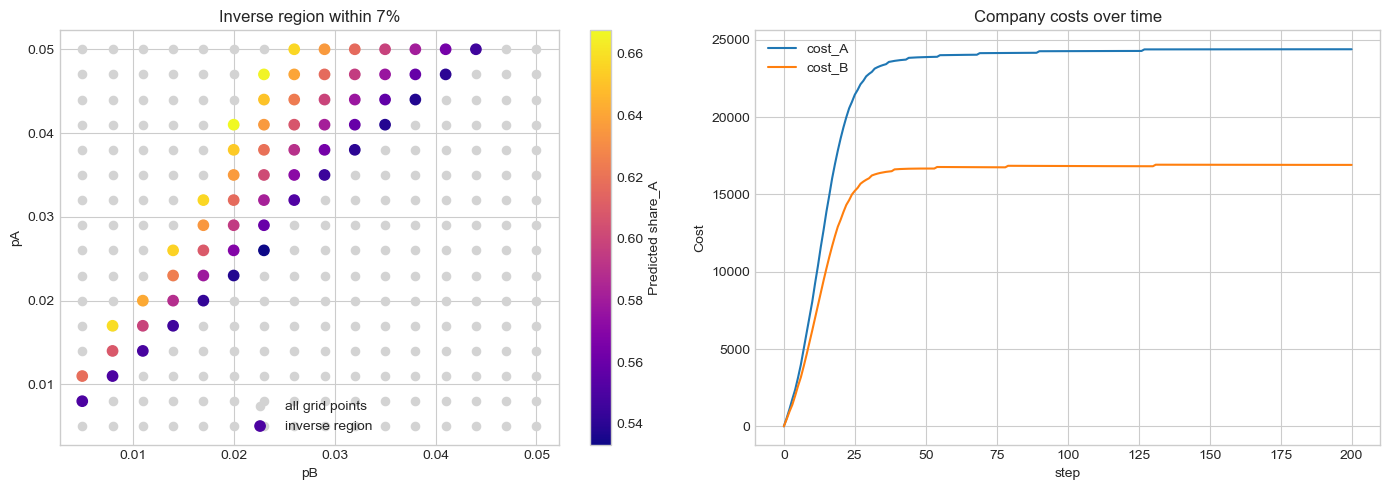

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(dataset['pB'], dataset['pA'], c='lightgray', s=35, label='all grid points')
scatter = axes[0].scatter(
    inverse_region['pB'],
    inverse_region['pA'],
    c=inverse_region['predicted_share_A'],
    cmap='plasma',
    s=55,
    label='inverse region'
)
axes[0].set_xlabel('pB')
axes[0].set_ylabel('pA')
axes[0].set_title('Inverse region within 7%')
axes[0].legend()
fig.colorbar(scatter, ax=axes[0], label='Predicted share_A')

history.plot(x='step', y=['cost_A', 'cost_B'], ax=axes[1])
axes[1].set_title('Company costs over time')
axes[1].set_ylabel('Cost')
plt.tight_layout()
